# Latent-Space Evaluation — Pooled PCA Recovery

Does each model recover the **covariance geometry** of the ground-truth GTEx
manifold? This is the fourth orthogonal eval axis, alongside population
(per-sample), gene-wise (per-gene), and single-subject (per-subject).

Replicates the analyses in `notebooks/pca_cached_predictions.ipynb`, but now
backed by `src/eval_utils/eval_latent.py` and consuming the **canonical wide
prediction tables** (the same `build_global_prediction_tables` /
`make_prediction_eval_view` path as every other eval notebook). The legacy
notebook still runs against `results_eda.py` — this is purely additive.

Each PCA fit matrix has shape

$$X \in \mathbb{R}^{n_{\text{samples}} \times n_{\text{genes}}},$$

where $n_{\text{samples}}$ is the pooled count of **strict held-out**
subject-parcel rows (not subjects, not the full atlas) — recovery can only be
scored where ground truth exists.

## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Section 1 — Standard pooled PCA (variance spectra + recovery)
- Section 2 — Within-parcel demeaned PCA
- Section 3 — Within-parcel variance effects
- Section 4 — Sample x gene heatmaps
- Section 5 — Parcel prediction scatters (from `eval_population`)

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
import src.eval_utils.eval_latent as eval_latent
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
importlib.reload(eval_latent)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *
from src.eval_utils.eval_latent import *

## Notebook Configuration

Global / cross-section knobs in the next cell. Per-section knobs live in
mini-config cells immediately above their use sites for fluid iteration.

In [3]:
# === Global config ===
set_academic_style()

# Switch this one value when comparing cache families.
#   c        = centroid matching, covariate-aware ComBat
#   cv       = centroid+volume matching, covariate-aware ComBat
#   cv_nocov = centroid+volume matching, no ComBat covariates
CACHE_VARIANT = 'cv'  # 'c' | 'cv' | 'cv_nocov'
CACHE_VARIANTS = {
    'c': dict(
        cache_root='out/loro_subject_cache_c',
        combat_use_covariates=True,
        matching_policy='centroids',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv': dict(
        cache_root='out/loro_subject_cache_cv_shrink',
        combat_use_covariates=True,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv_nocov': dict(
        cache_root='out/loro_subject_cache_cv_nocov',
        combat_use_covariates=False,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
}
CACHE_CFG = CACHE_VARIANTS[CACHE_VARIANT]

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root=CACHE_CFG['cache_root'],
    gene_scope='allgenes',
    combat_use_covariates=CACHE_CFG['combat_use_covariates'],
    matching_policy=CACHE_CFG['matching_policy'],
    matching_policy_hemi_mode=CACHE_CFG['matching_policy_hemi_mode'],
    collapse_cerebellum=CACHE_CFG['collapse_cerebellum'],
    gtex_rep_mode='centroid',
    gtex_hemi_mode='mirror_left',
)
print('cache variant:', CACHE_VARIANT)
print('cache root:', CFG.cache_root)
print('analysis scope:', CFG.gene_scope)
print('combat_use_covariates:', CFG.combat_use_covariates)
print('matching:', CFG.matching_policy, CFG.matching_policy_hemi_mode, 'collapse_cerebellum=', CFG.collapse_cerebellum)

MODELS                       = ['naive', 'dlam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = False

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse

# PCA defaults (per-section configs can override).
NUM_PCS         = 300            # clamped to min(n_samples, n_genes) automatically
RECOVERY_METRIC = 'score_pearson'  # score_pearson | score_spearman | score_r2 | score_rmse
PCA_CACHE       = True           # disk-cache compute_pca_* under notebooks/cache/pca_*
PCA_FORCE_REBUILD = False


cache variant: cv
cache root: out/loro_subject_cache_cv_shrink
analysis scope: allgenes
combat_use_covariates: True
matching: centroids_and_volumes force_left collapse_cerebellum= False


## Shared Reconstruction

`PREPOST` + the canonical wide truth/pred tables. `build_panel_view` wraps
`make_prediction_eval_view` with the notebook defaults so each section gets a
panel-scoped view in one line. All rows are strict held-out
(`loro_eval_mask`) — the latent analyses are strict-scoped for free.

In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:   ', len(PREPOST['genes']))
print('parcels: ', PREPOST['raw_cube'].shape[1])

[prepost_cache] hit  notebooks/cache/prepost/b8c1d9d0503e5133.pkl  (8961.2 MB)
subjects: 318
genes:    11704
parcels:  150


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2869, 11722), 'dlam': (2869, 11722)}


In [6]:
# Panel-scoped view from globals (truth_df / pred_dfs / VIEW_SUBSET) in one line.
def build_panel_view(gene_list_path=None, models=None, **overrides):
    subset = {**VIEW_SUBSET, **overrides}
    return make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=gene_list_path,
        models=list(models) if models is not None else MODELS,
        **subset,
    )

## Section 1 — Standard Pooled PCA

PCA is fit on the truth matrix; sklearn centers each gene globally across all
pooled samples. Each model's prediction matrix is projected into that same
truth basis.

**Why naive can look nontrivial here:** pooled PCA still contains parcel fixed
effects, and naive fill reproduces parcel template structure well — so it
scores on parcel-driven PCs even where it misses subject-specific variation.
Section 2 removes that confound.

In [7]:
# Section 1 config — gene panel + compute knobs
S1_GENE_LIST_PATH = None        # None = all genes; e.g. 'gtex_100hvg', 'richiardi2015', or a path
S1_NUM_PCS        = NUM_PCS
S1_DEMEAN_MODE    = 'none'

# Plot knobs
S1_SPECTRA_SOURCES   = None      # None = truth + all models overlaid; or e.g. ['truth']
S1_SPECTRA_X_STRIDE  = 20
S1_RECOVERY_X_STRIDE = 20
S1_LOWESS_FRAC       = 0.20

In [8]:
# Build the panel-scoped view, then compute recovery + intrinsic variance spectra (cached).
s1_view = build_panel_view(S1_GENE_LIST_PATH)
print('view genes:', len(s1_view['genes']),
      ' samples:', len(s1_view['truth_df']))

pc_df, pc_summary = compute_pca_recovery(
    s1_view, num_pcs=S1_NUM_PCS, demean_mode=S1_DEMEAN_MODE, models=MODELS,
    cache=PCA_CACHE, force_rebuild=PCA_FORCE_REBUILD,
)
spectra_df, spectra_summary = compute_pca_variance_spectra(
    s1_view, num_pcs=S1_NUM_PCS, demean_mode=S1_DEMEAN_MODE, models=MODELS,
    cache=PCA_CACHE, force_rebuild=PCA_FORCE_REBUILD,
)
display(pc_summary)
display(spectra_summary)

view genes: 11704  samples: 2869


[pca_cache] wrote notebooks/cache/pca_recovery/58e951a53f3c7c58.pkl
[pca_cache] wrote notebooks/cache/pca_spectra/807a6b6cdabd6898.pkl


,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,demean_mode,panel_label
0,naive,0.025720,0.404022,0.250546,145,2869,11704,300,none,All Genes
1,dlam,0.349013,0.456062,0.361663,145,2869,11704,300,none,All Genes


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,demean_mode,panel_label
0,truth,0.309224,145,2869,11704,300,none,All Genes
1,naive,0.492057,6,2869,11704,300,none,All Genes
2,dlam,0.467892,29,2869,11704,300,none,All Genes


### Variance spectra by source

Intrinsic variance geometry of the truth matrix and each model matrix,
each fit separately. Answers: how many PCs does *this* source need to explain
most of its own variance? Sources are overlaid for direct comparison.

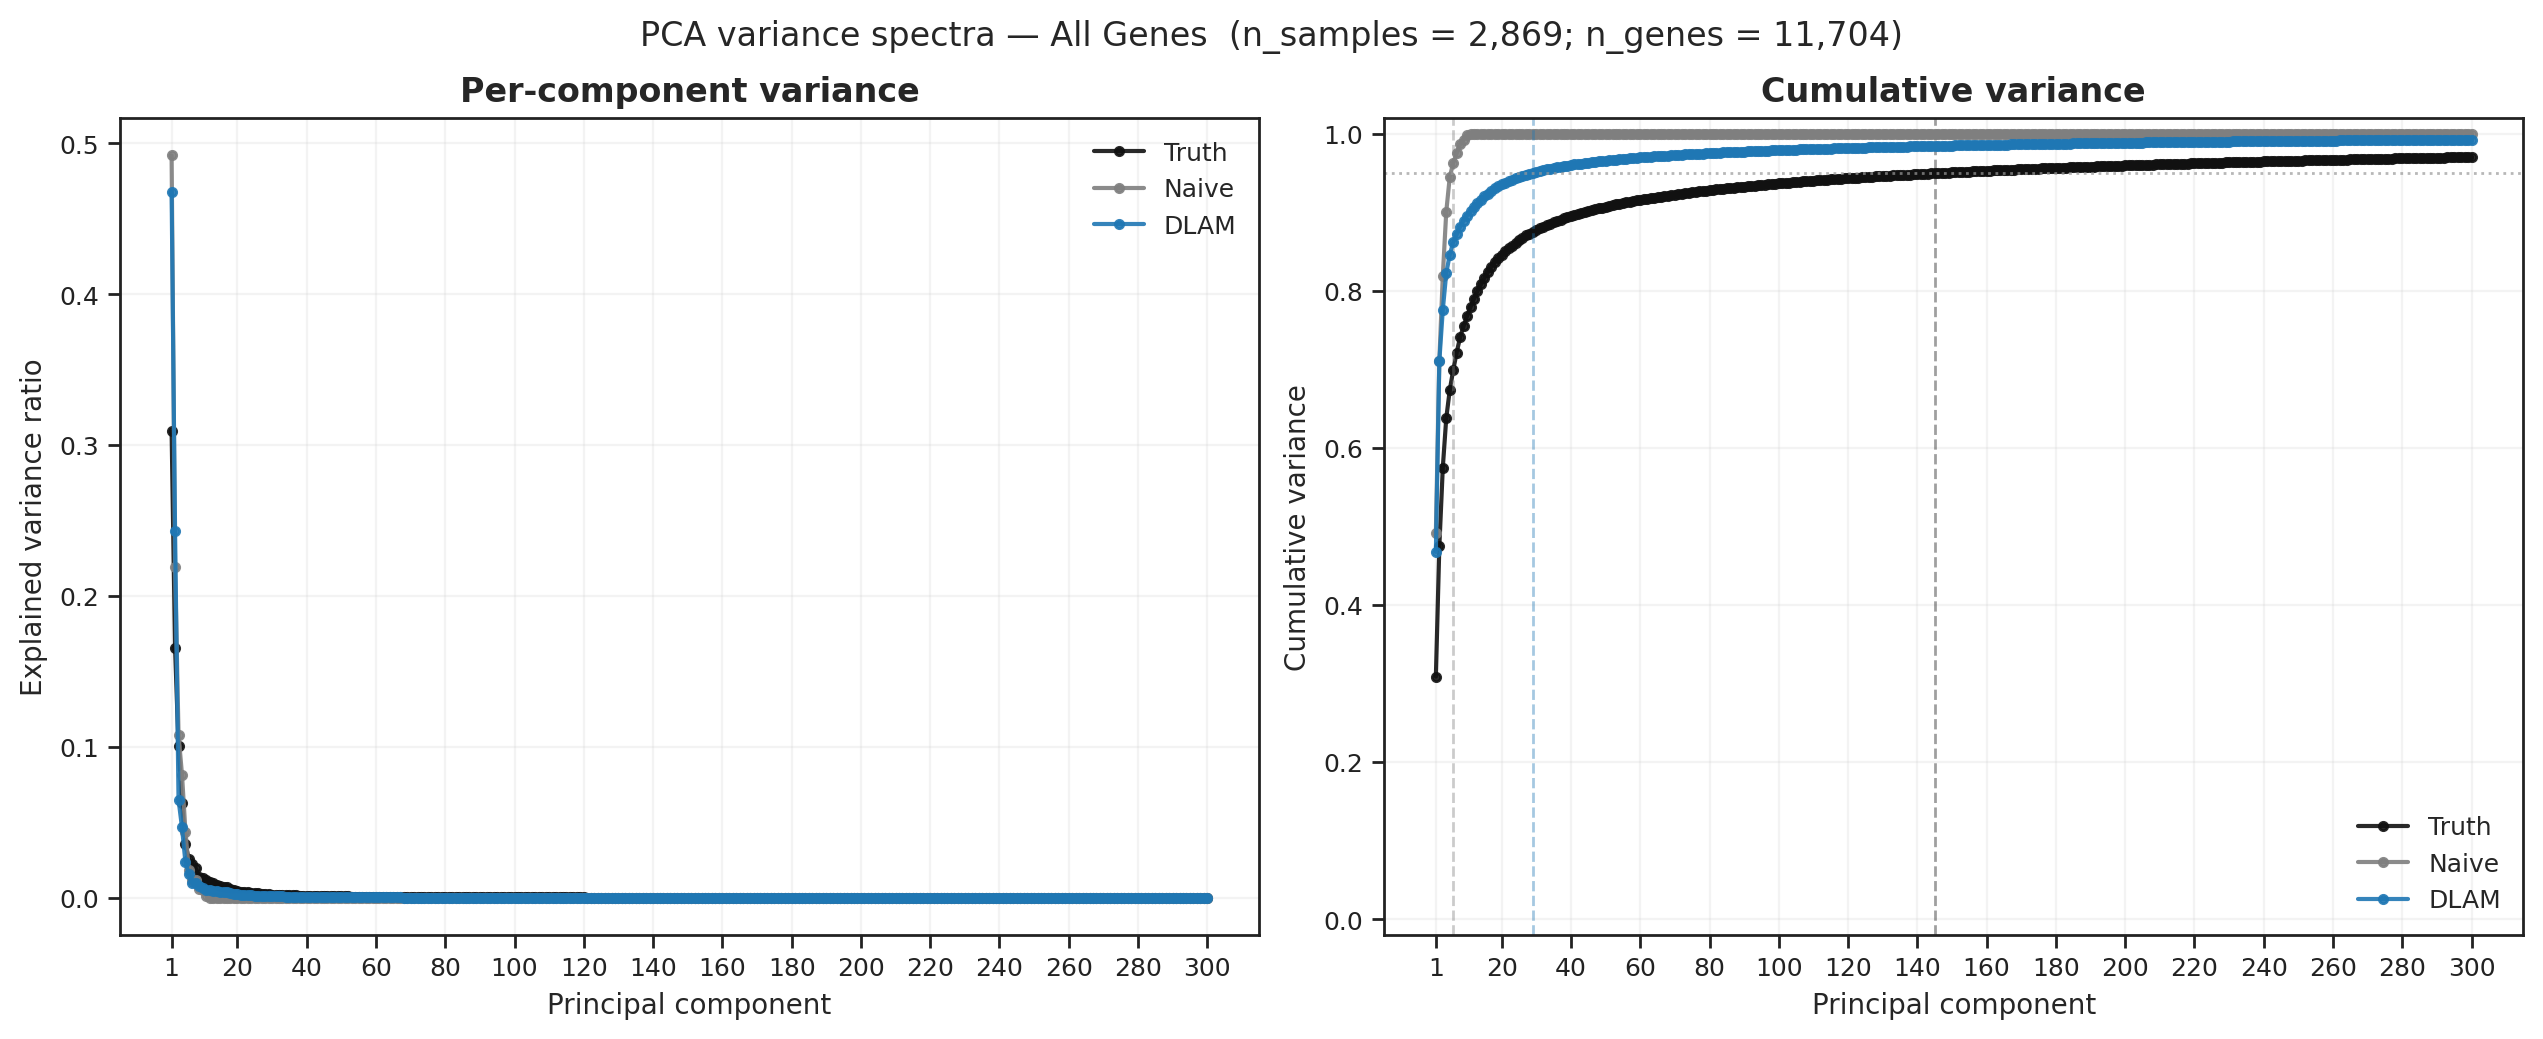

In [9]:
fig, axes, _ = plot_pca_variance_spectra(
    spectra_df,
    sources=S1_SPECTRA_SOURCES,
    x_label_stride=S1_SPECTRA_X_STRIDE,
)

### Ground-truth PCA recovery

Different question from the spectrum: the PCA basis is always truth, and for
each component `j` we ask how well predicted PC scores align with true PC
scores across pooled samples. The dashed rule marks the 95% true-data
variance cutoff; the `Truth` series is the self-recovery ceiling.

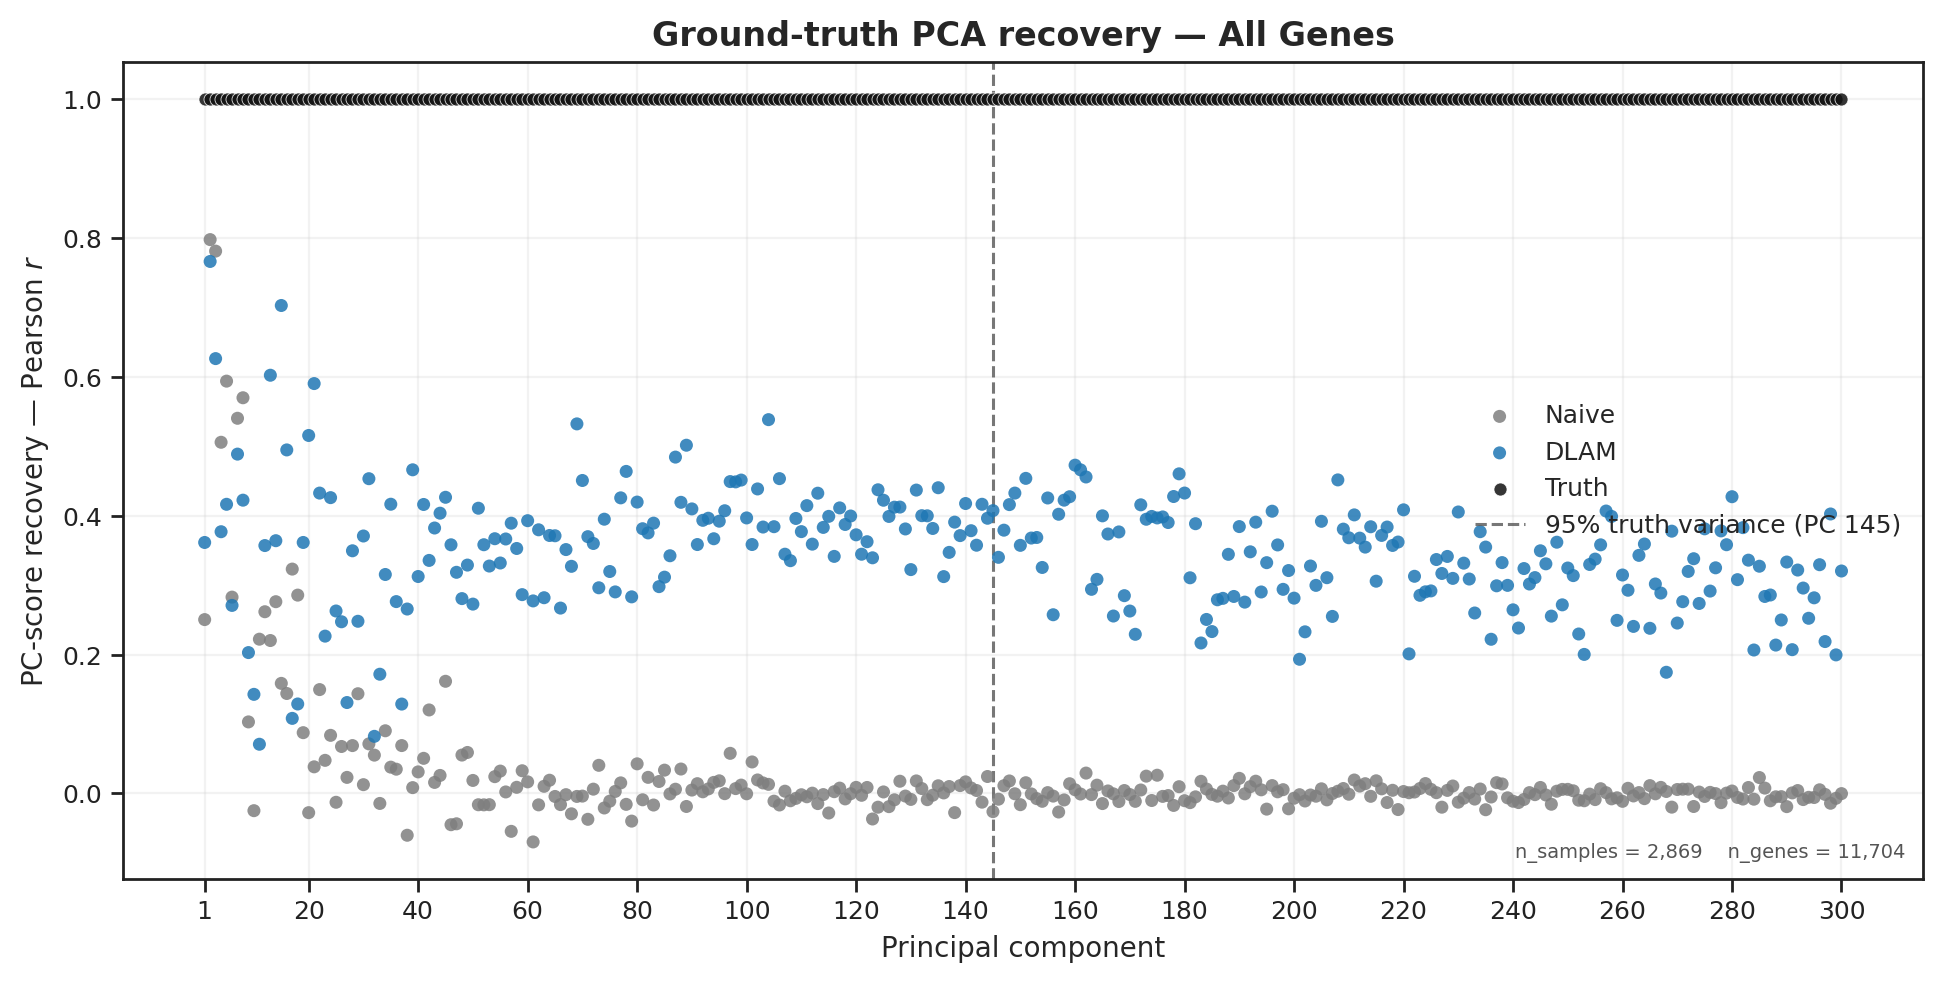

In [10]:
# Raw component-wise points.
fig, ax, _ = plot_pca_recovery(
    pc_df, metric=RECOVERY_METRIC, models=MODELS,
    show_truth=True, show_lines=False,
    x_label_stride=S1_RECOVERY_X_STRIDE,
)

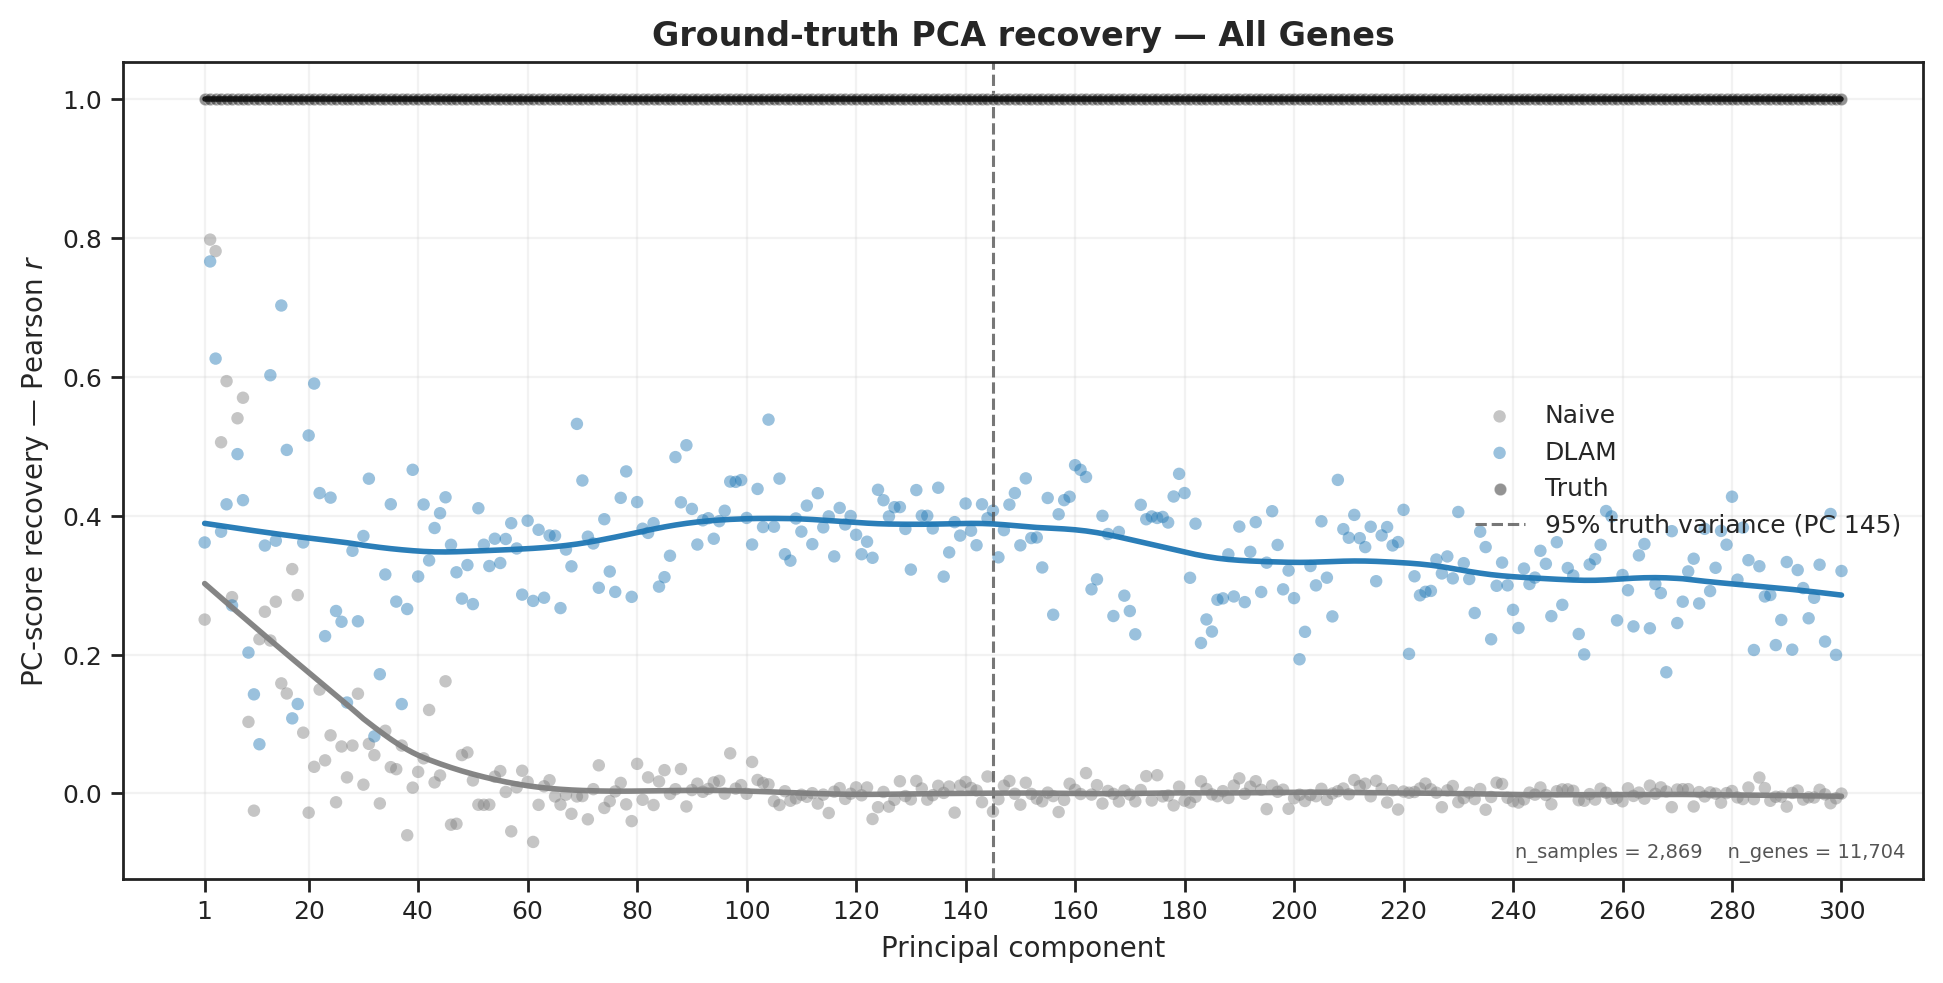

In [11]:
# LOWESS trend overlay — descriptive summary of the recovery profile.
fig, ax, _ = plot_pca_recovery(
    pc_df, metric=RECOVERY_METRIC, models=MODELS,
    show_truth=True, show_fit='lowess', lowess_frac=S1_LOWESS_FRAC,
    x_label_stride=S1_RECOVERY_X_STRIDE,
)

## Section 2 — Within-Parcel Demeaned PCA

Explicitly projects out the parcel fixed effect. For sample $i$ in parcel
$p(i)$ and gene $g$, define the truth parcel mean

$$\bar{x}_{p,g} = \frac{1}{n_p} \sum_{i \,:\, p(i) = p} x_{i,g},$$

then subtract it within parcel from both truth and every prediction:

$$r_{i,g} = x_{i,g} - \bar{x}_{p(i),g}.$$

PCA is fit on the residual matrix $R = [\,r_{i,g}\,]$, after its usual global
gene-wise centering. The first step projects out the parcel fixed effect; the
second recenters the residual feature space.

**Expected:** naive fill mostly captures parcel templates, so its residual
structure should collapse toward zero. DLAM should stay above zero if
they reconstruct subject-varying residuals within parcel.

In [12]:
# Section 2 config
S2_GENE_LIST_PATH = S1_GENE_LIST_PATH    # reuse Section 1's panel by default
S2_NUM_PCS        = NUM_PCS
S2_DEMEAN_MODE    = 'within_parcel'

S2_SPECTRA_SOURCES   = None
S2_SPECTRA_X_STRIDE  = 20
S2_RECOVERY_X_STRIDE = 20
S2_LOWESS_FRAC       = 0.20

In [13]:
s2_view = build_panel_view(S2_GENE_LIST_PATH)

pc_df_dm, pc_summary_dm = compute_pca_recovery(
    s2_view, num_pcs=S2_NUM_PCS, demean_mode=S2_DEMEAN_MODE, models=MODELS,
    cache=PCA_CACHE, force_rebuild=PCA_FORCE_REBUILD,
)
spectra_df_dm, spectra_summary_dm = compute_pca_variance_spectra(
    s2_view, num_pcs=S2_NUM_PCS, demean_mode=S2_DEMEAN_MODE, models=MODELS,
    cache=PCA_CACHE, force_rebuild=PCA_FORCE_REBUILD,
)
display(pc_summary_dm)
display(spectra_summary_dm)

[pca_cache] wrote notebooks/cache/pca_recovery/36ae1bfad15864c0.pkl
[pca_cache] wrote notebooks/cache/pca_spectra/8f6492a45f18e50f.pkl


,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,demean_mode,panel_label
0,naive,-0.000246,-0.000275,-0.000208,259,2869,11704,300,within_parcel,All Genes
1,dlam,0.288256,0.295175,0.312721,259,2869,11704,300,within_parcel,All Genes


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,demean_mode,panel_label
0,truth,0.426306,259,2869,11704,300,within_parcel,All Genes
1,naive,0.388558,8,2869,11704,300,within_parcel,All Genes
2,dlam,0.430368,31,2869,11704,300,within_parcel,All Genes


### Within-parcel demeaned variance spectra

Residual variance after truth parcel means are removed — focused on
subject-specific within-parcel variation.

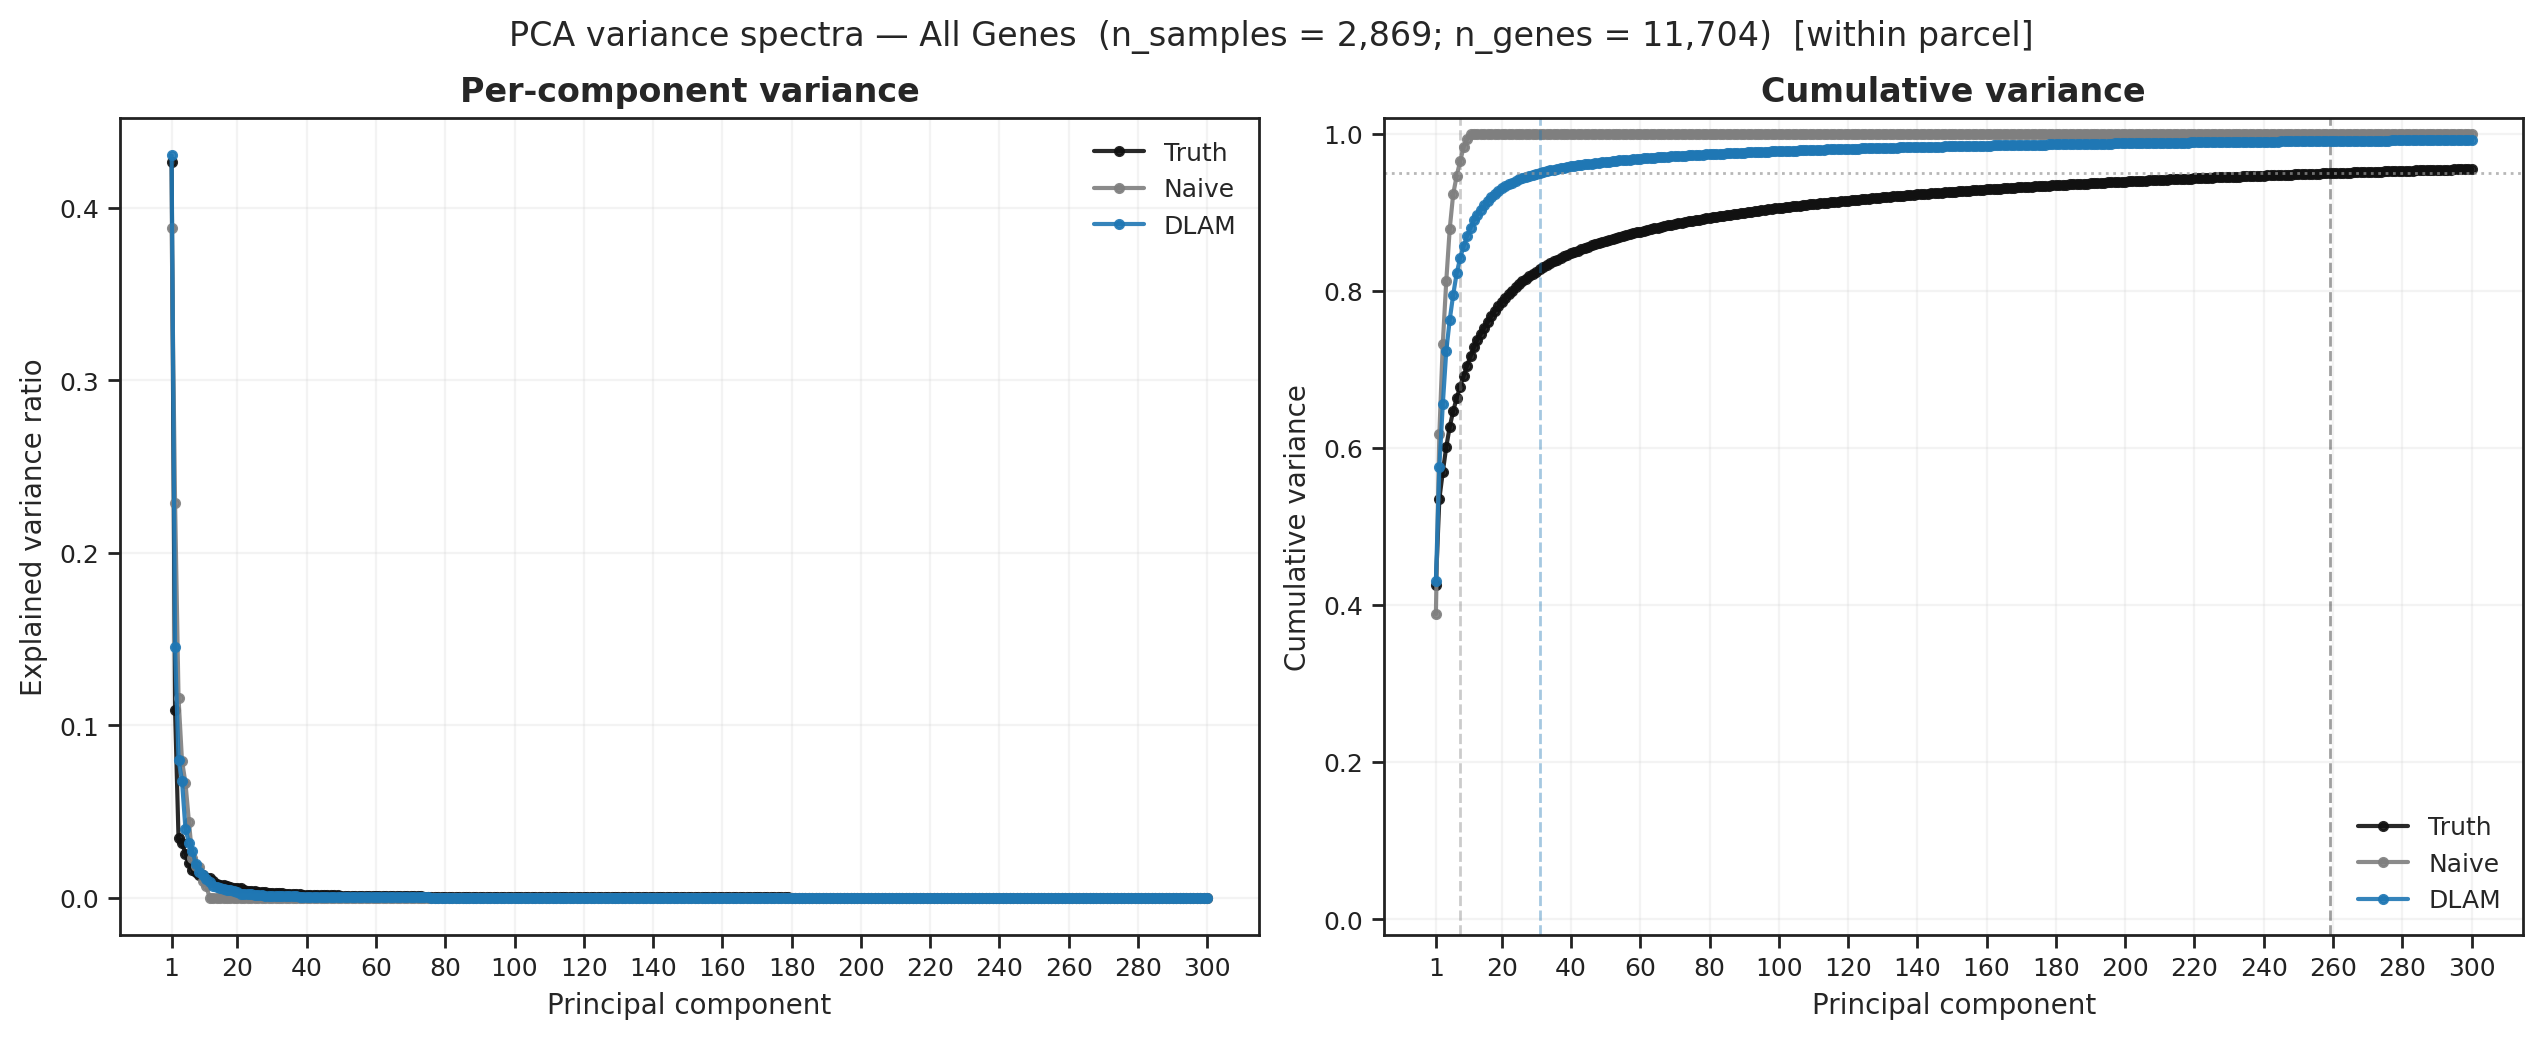

In [14]:
fig, axes, _ = plot_pca_variance_spectra(
    spectra_df_dm,
    sources=S2_SPECTRA_SOURCES,
    x_label_stride=S2_SPECTRA_X_STRIDE,
)

### Within-parcel demeaned recovery

Recovery in the parcel-demeaned residual space — much closer to a
subject-specific variance question than standard pooled PCA.

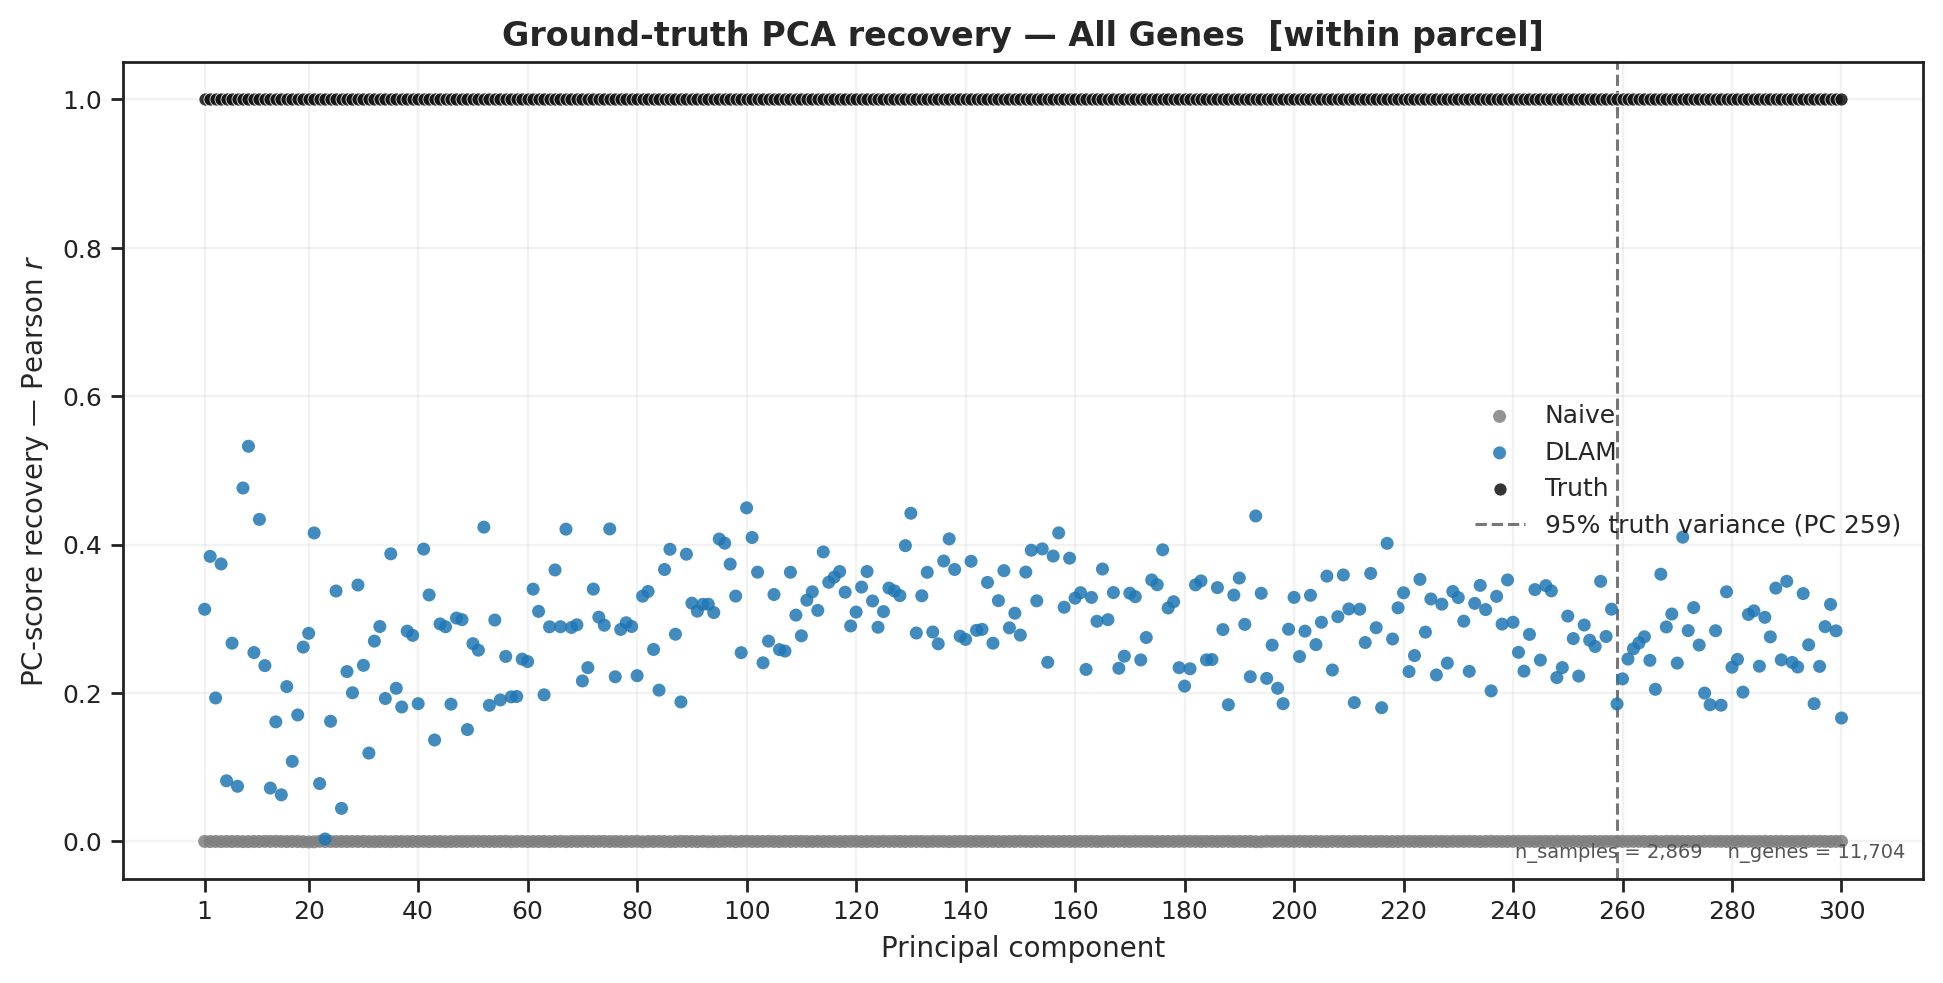

In [15]:
fig, ax, _ = plot_pca_recovery(
    pc_df_dm, metric=RECOVERY_METRIC, models=MODELS,
    show_truth=True, show_lines=False,
    x_label_stride=S2_RECOVERY_X_STRIDE,
)

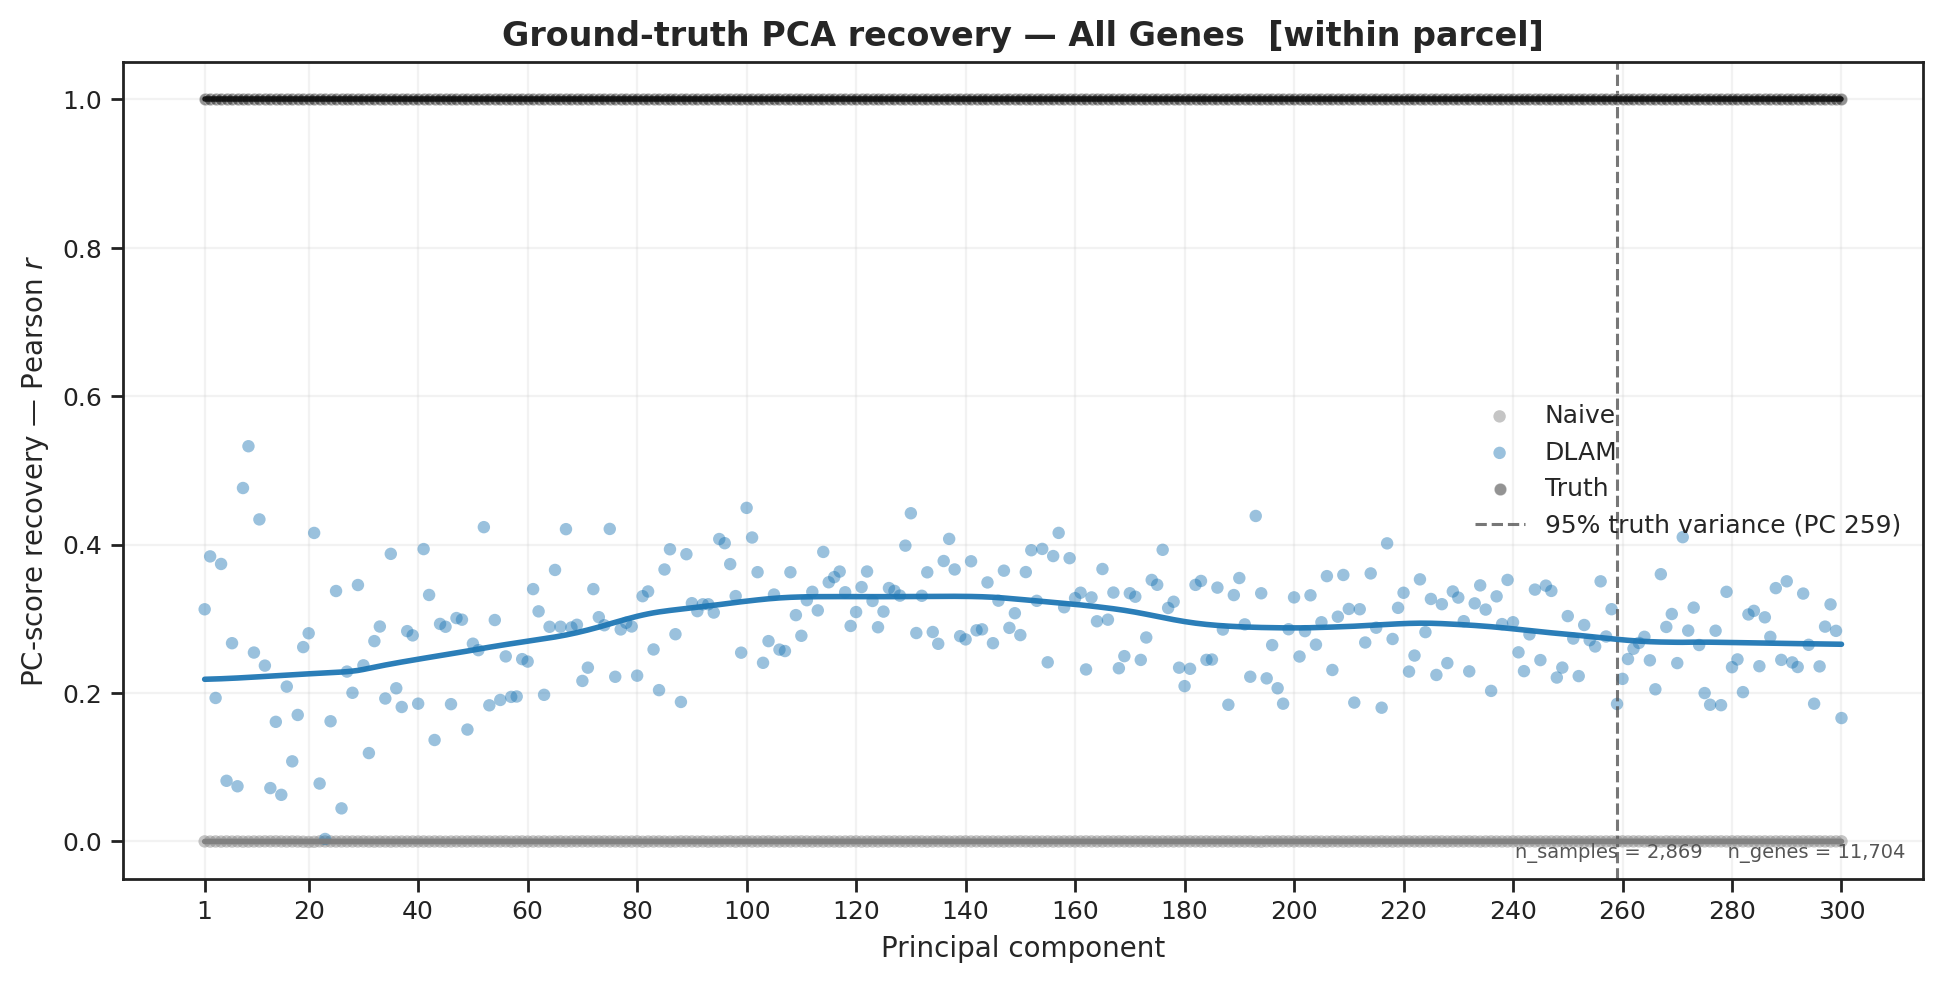

In [16]:
fig, ax, _ = plot_pca_recovery(
    pc_df_dm, metric=RECOVERY_METRIC, models=MODELS,
    show_truth=True, show_fit='lowess', lowess_frac=S2_LOWESS_FRAC,
    x_label_stride=S2_RECOVERY_X_STRIDE,
)

## Section 3 — Within-Parcel Variance Effects

Companion diagnostic. PCA recovery asks whether predicted variation *aligns*
with the true latent axes; this asks whether the model produces
subject-to-subject variation within a parcel **at all**. A model can have
ample within-parcel variance yet still fail to align it with the dominant
true PCA directions.

In [17]:
# Section 3 config
S3_GENE_LIST_PATH = S1_GENE_LIST_PATH    # reuse Section 1's panel by default
S3_LABEL_MODE     = 'gtex'               # parcel labels: gtex | ahba
S3_SOURCES        = None                 # None = truth + all models

s3_view = build_panel_view(S3_GENE_LIST_PATH)
within_parcel_var_df = compute_within_parcel_variance(s3_view, models=MODELS)
display(
    within_parcel_var_df
    .groupby('source', as_index=False)['mean_within_parcel_std']
    .describe()
)

,source,count,mean,std,min,25%,50%,75%,max
0,dlam,12.0,0.232878,0.081172,0.107742,0.150600,0.272734,0.300882,0.328412
1,naive,12.0,0.000338,0.000106,0.000241,0.000259,0.000286,0.000384,0.000522
2,truth,12.0,0.262952,0.034914,0.188840,0.243202,0.276000,0.285852,0.301785


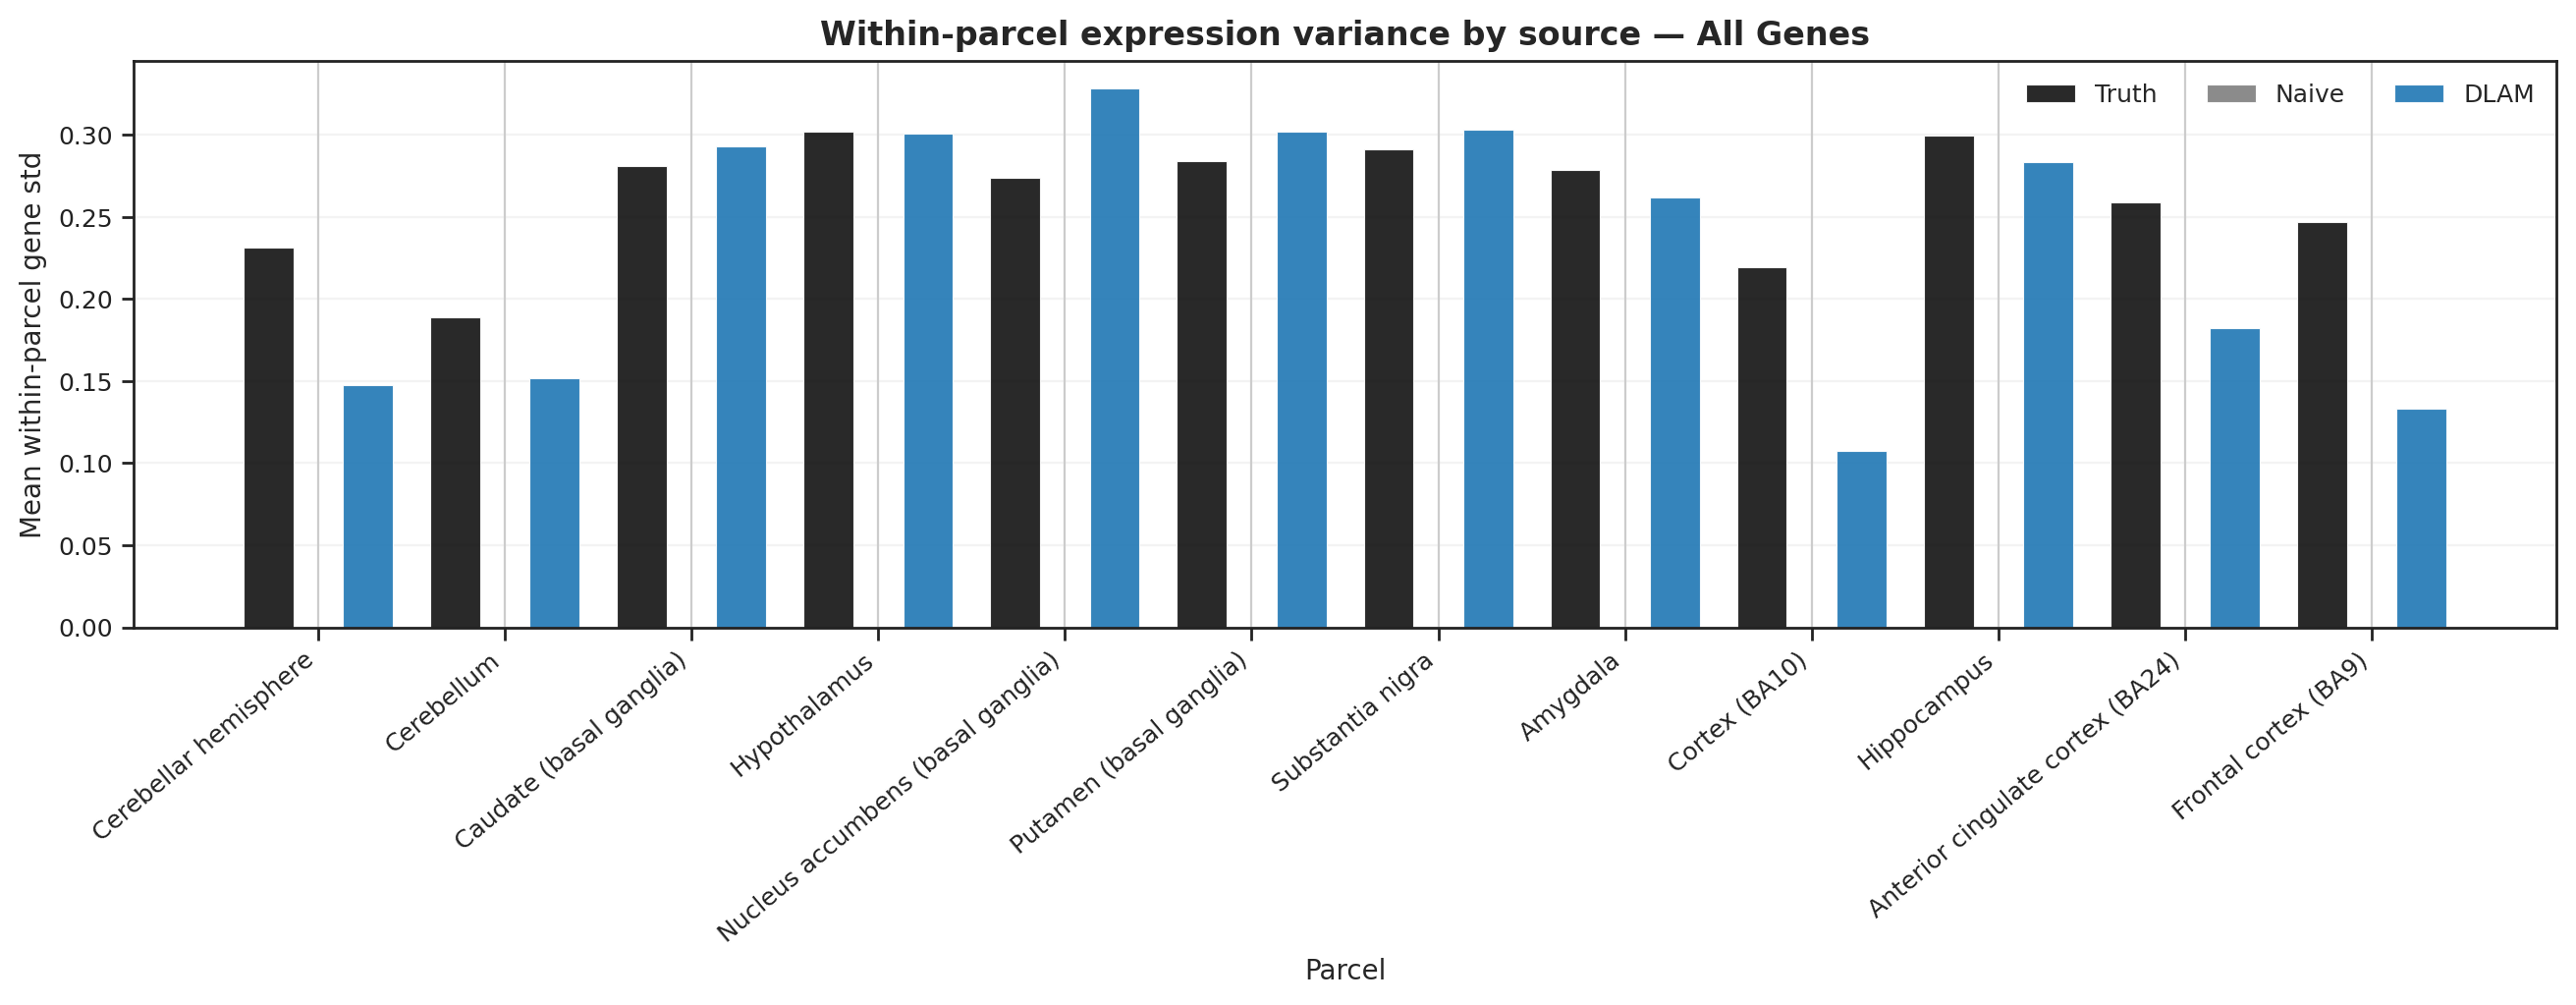

In [18]:
fig, ax, _ = plot_within_parcel_variance(
    within_parcel_var_df,
    prepost=PREPOST,
    label_mode=S3_LABEL_MODE,
    sources=S3_SOURCES,
)

## Section 4 — Sample x Gene Heatmaps

The pooled `samples x genes` matrix the models predict. One heatmap per
source, rows grouped by parcel (white separators + parcel labels). The truth
gene order is reused across sources so columns stay comparable — note where
prediction heatmaps lose the row-to-row (subject) structure visible in
truth.

In [19]:
# Section 4 config
S4_GENE_LIST_PATH  = S1_GENE_LIST_PATH
S4_GROUP_BY        = 'parcel'        # None | 'subject' | 'parcel'
S4_SAMPLE_N_GENES  = 100             # None = all genes in the panel
S4_RANDOM_SEED     = 42
S4_LABEL_MODE      = 'gtex'
S4_SOURCES         = ['truth'] + MODELS

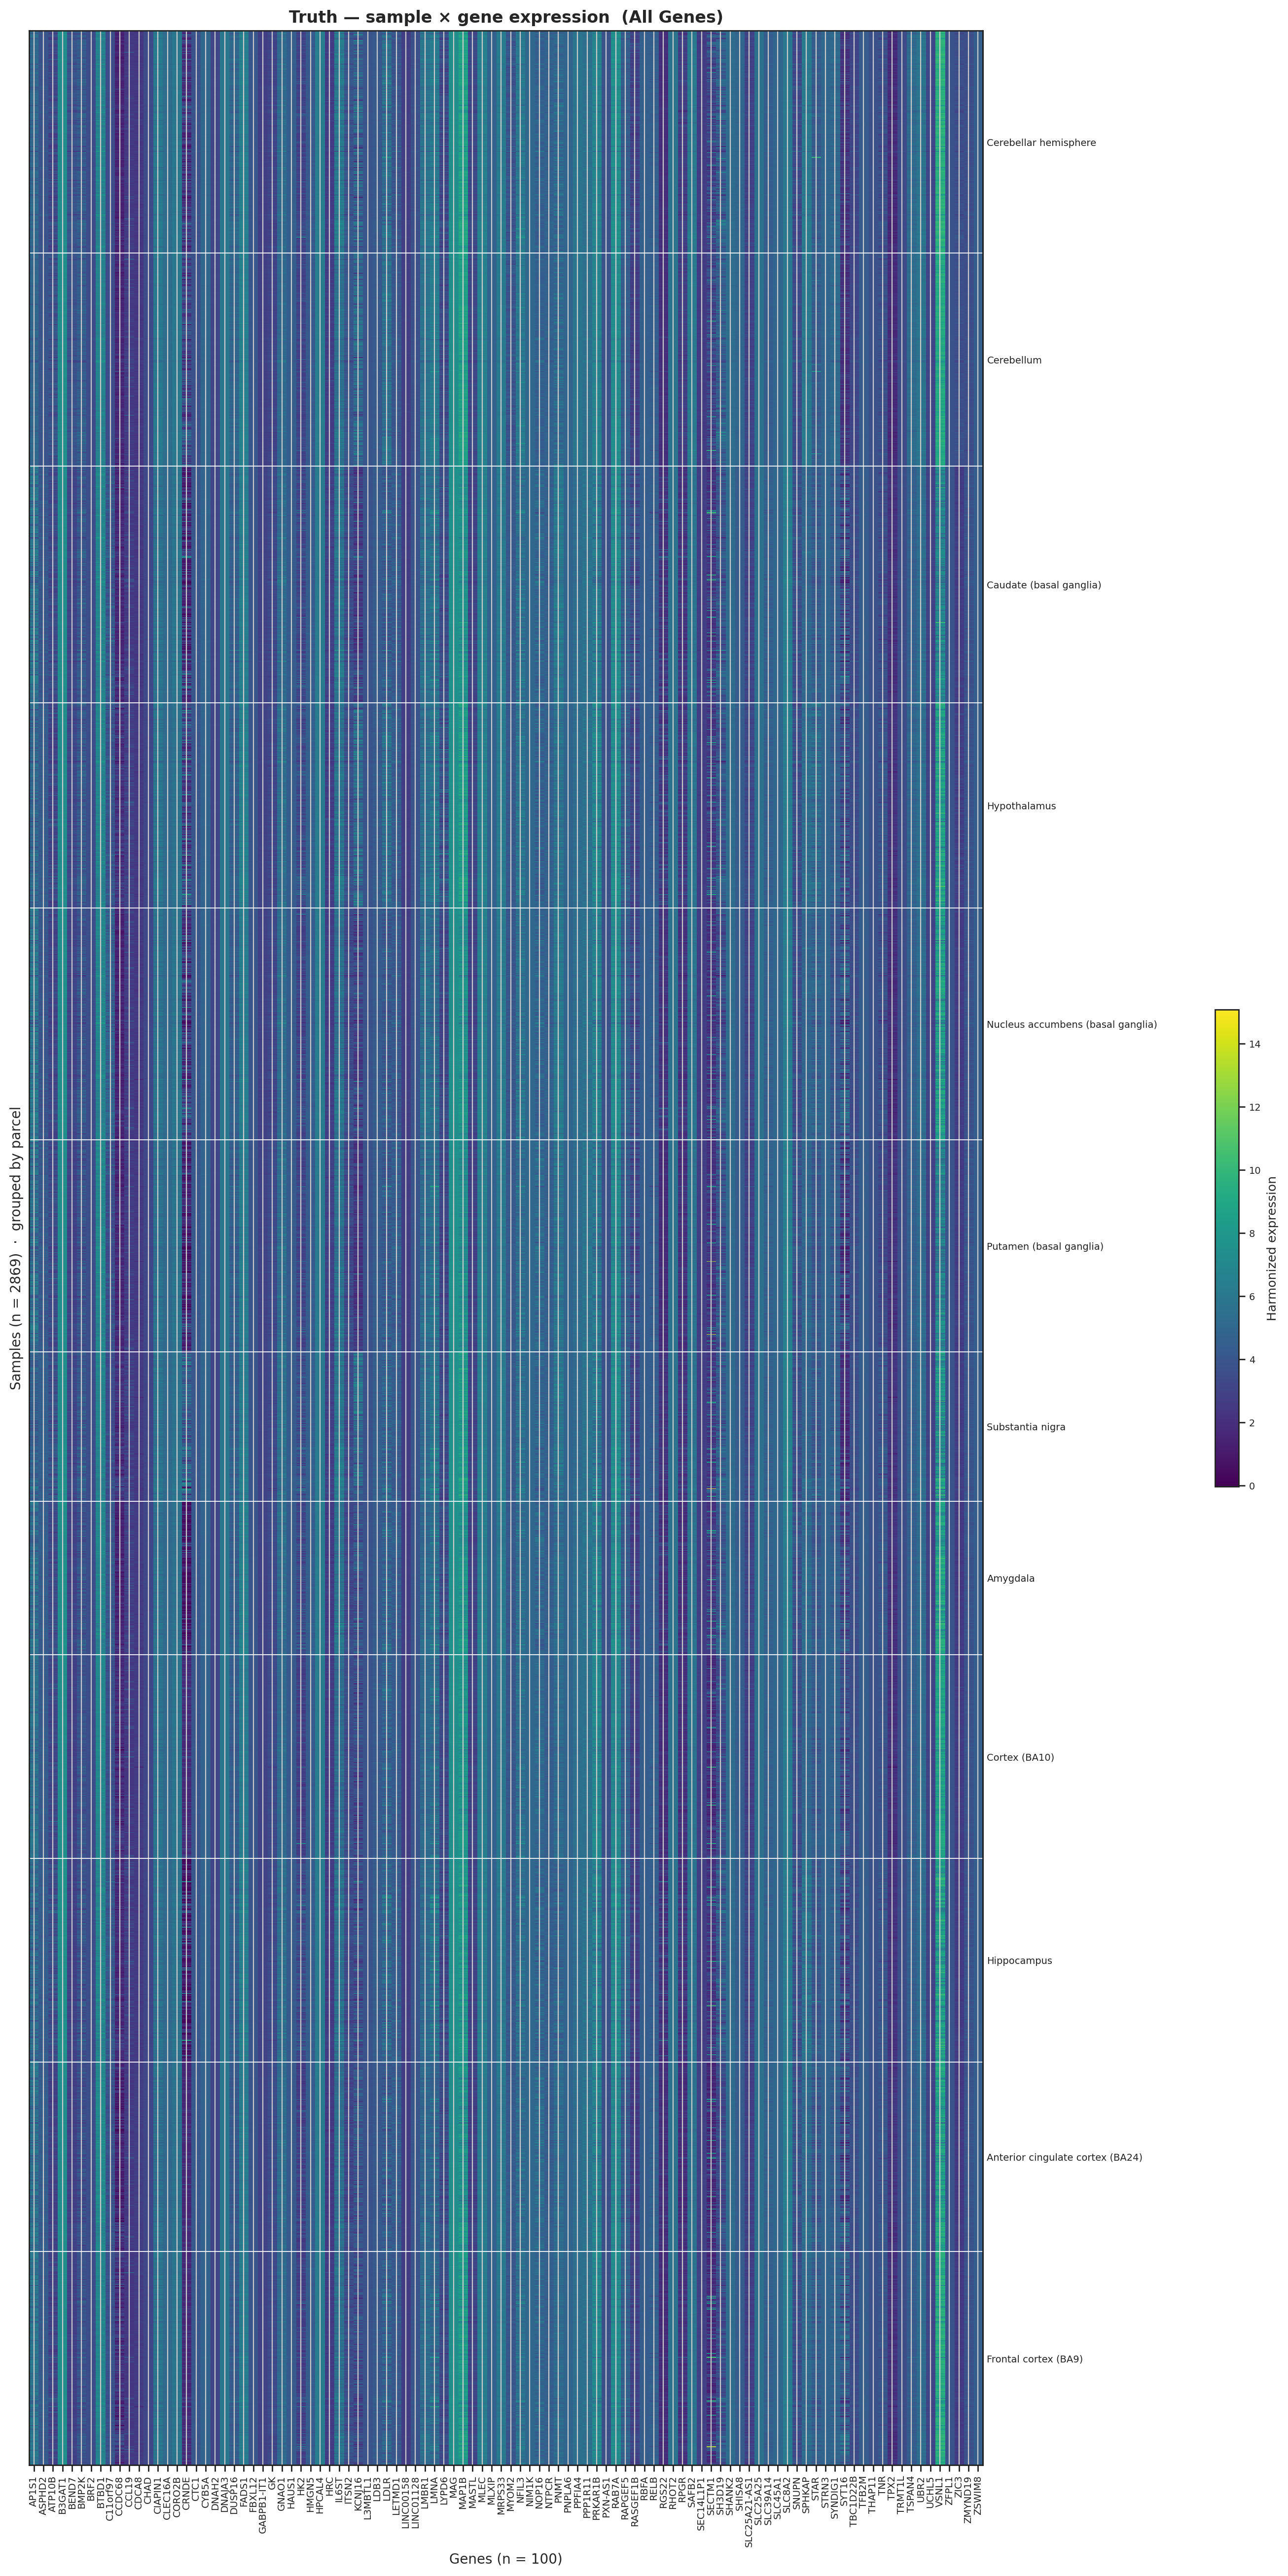

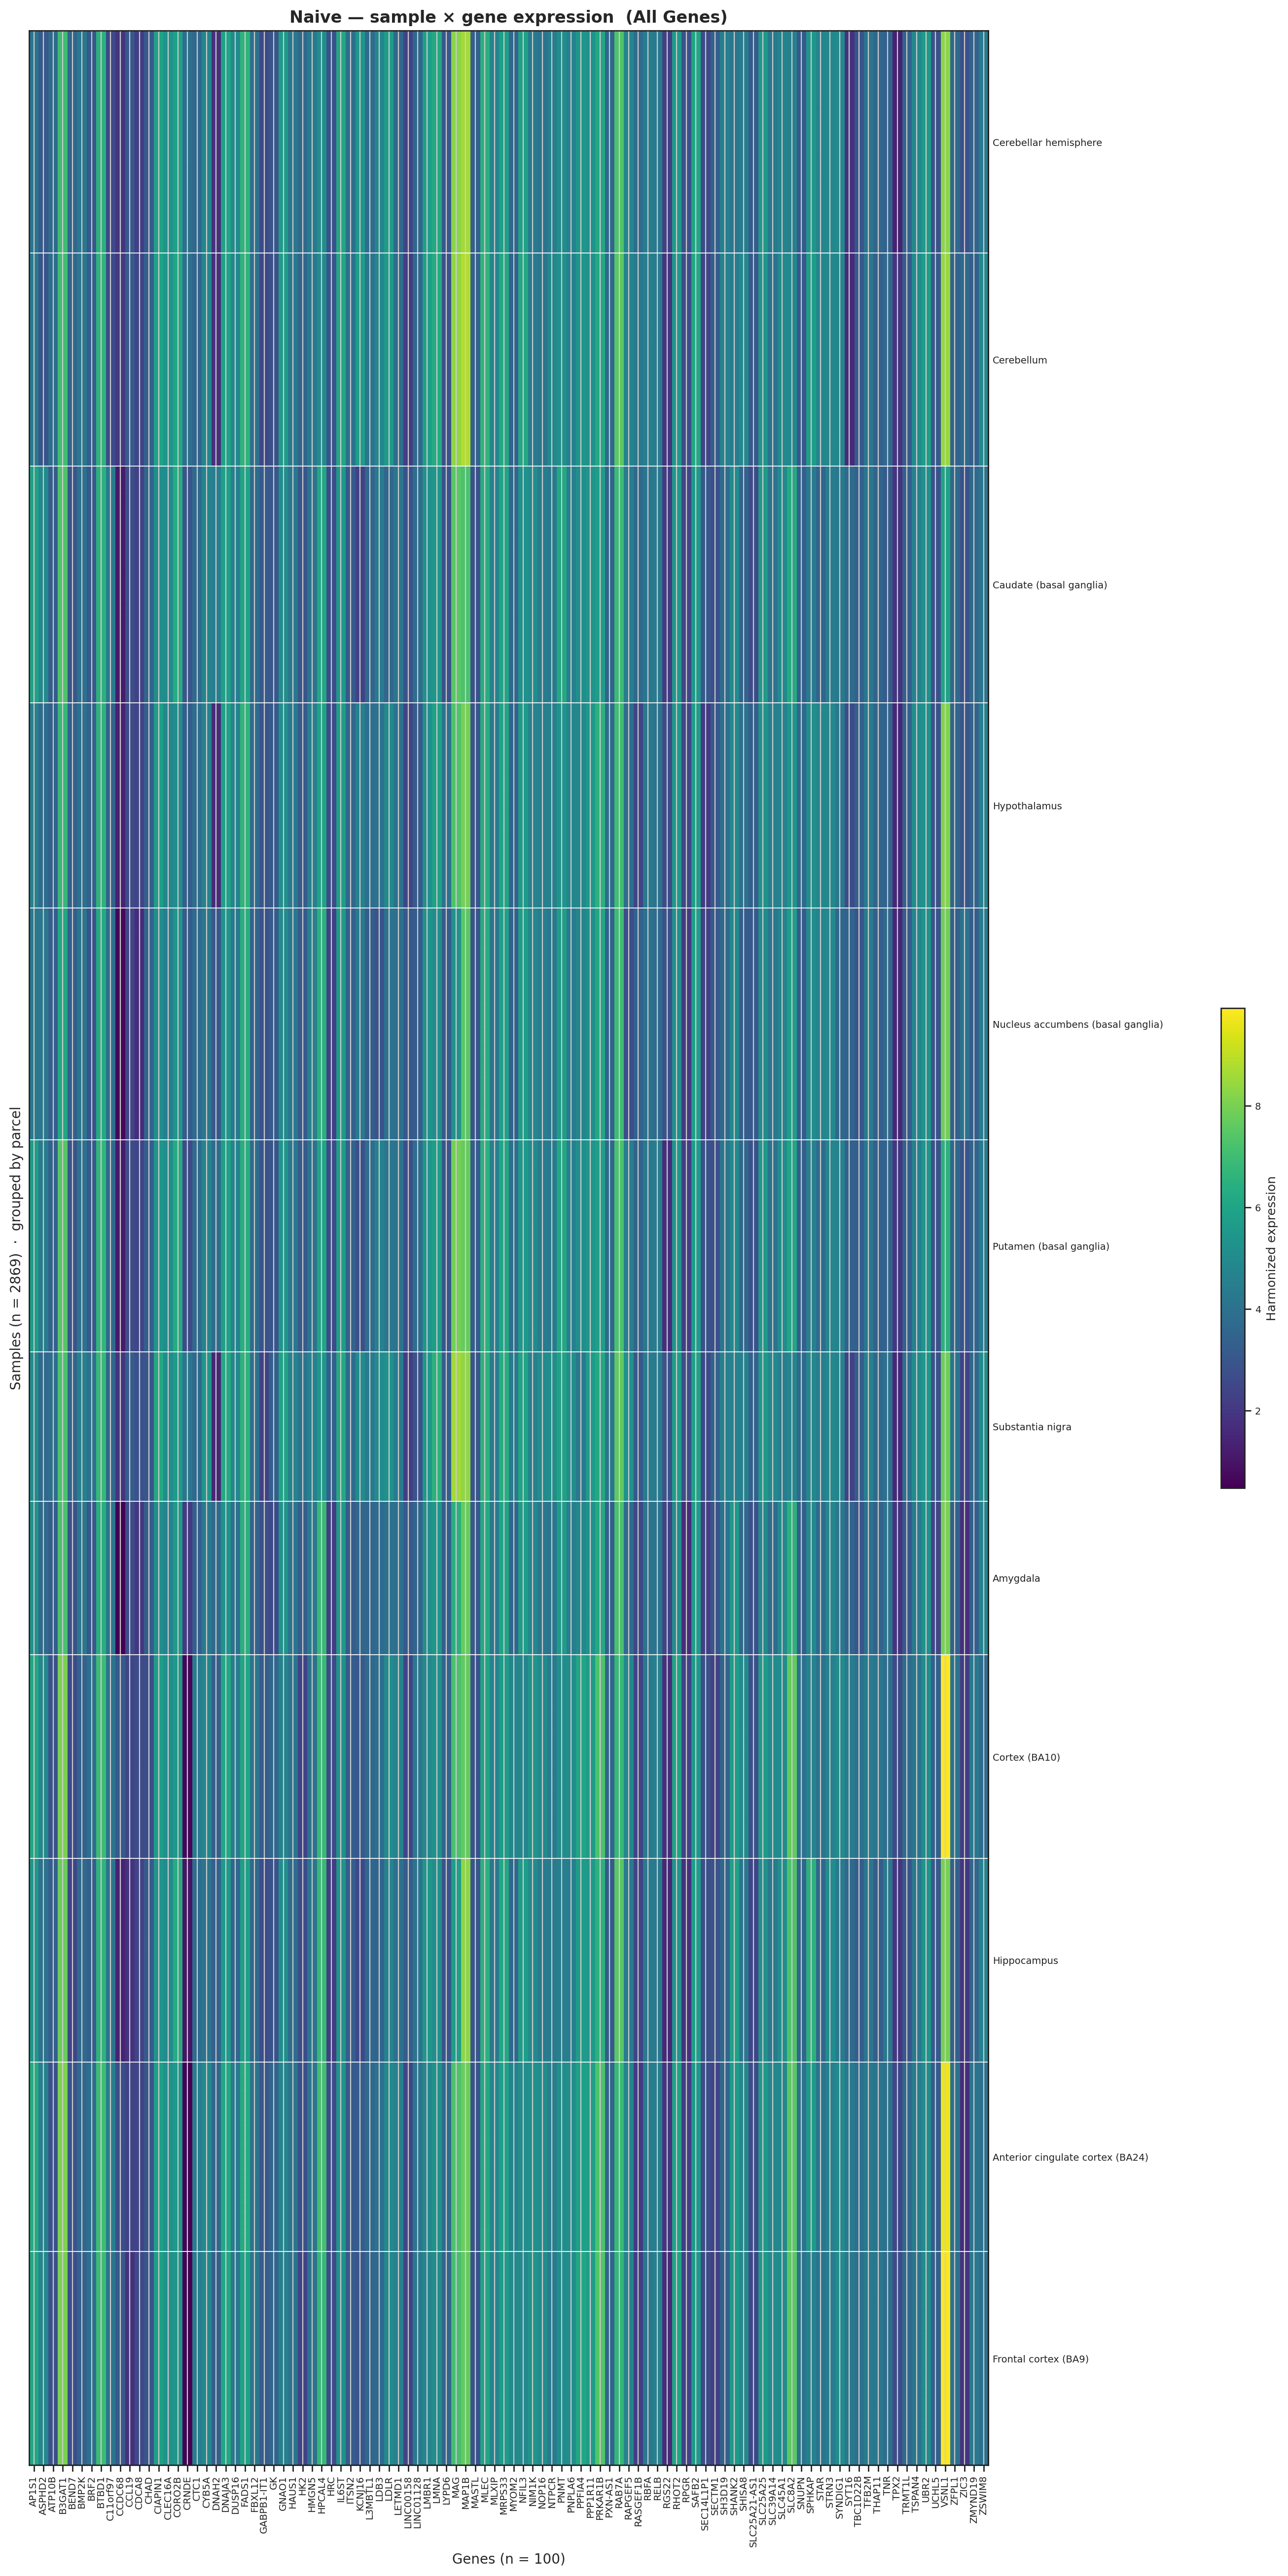

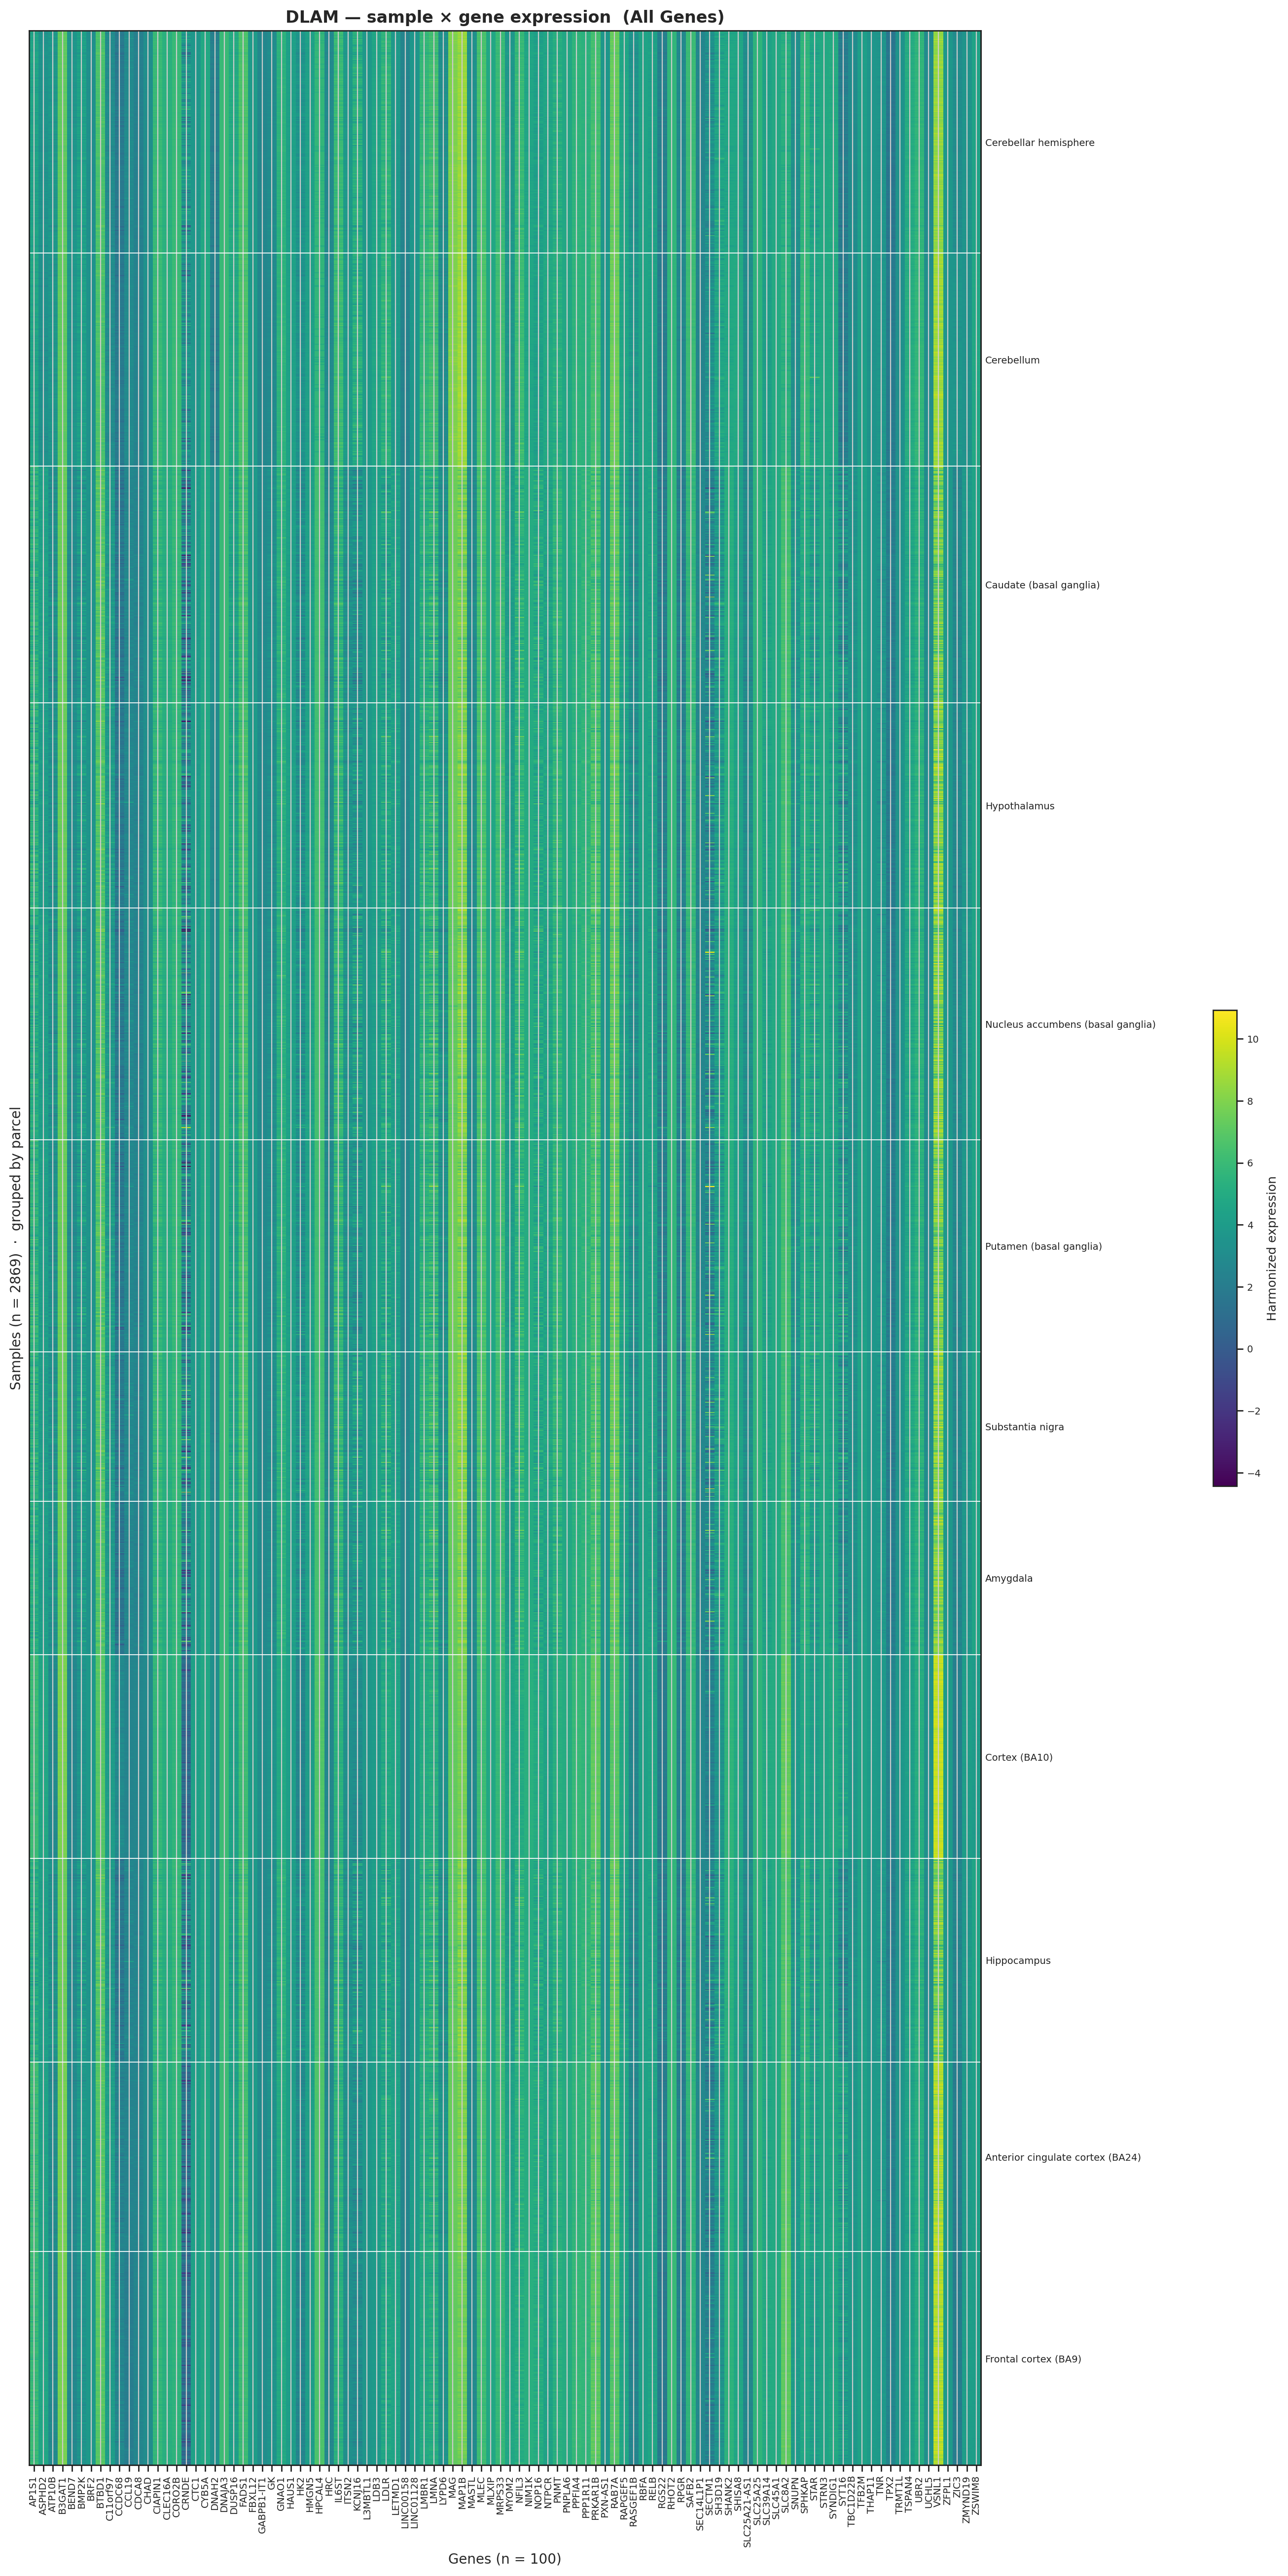

In [20]:
s4_view = build_panel_view(S4_GENE_LIST_PATH)

# Lock the gene order from truth so every panel shares columns.
_, _, s4_gene_order = plot_sample_gene_heatmap(
    s4_view, 'truth',
    prepost=PREPOST, label_mode=S4_LABEL_MODE,
    group_by=S4_GROUP_BY,
    sample_n_genes=S4_SAMPLE_N_GENES, random_seed=S4_RANDOM_SEED,
)

for _source in S4_SOURCES:
    if _source == 'truth':
        continue
    plot_sample_gene_heatmap(
        s4_view, _source,
        prepost=PREPOST, label_mode=S4_LABEL_MODE,
        group_by=S4_GROUP_BY,
        gene_order=s4_gene_order,   # reuse truth's columns
    )

## Section 5 — Parcel Prediction Scatters

Truth-vs-prediction scatter restricted to one parcel, all three models. This
reuses the **current** population scatter (`plot_global_prediction_scatter`)
on a parcel-filtered view — no bespoke PCA-notebook plotter. `color_by='gene'`
highlights the top-N genes; per-panel metric is annotated in the legend.

In [21]:
# Section 5 config
S5_TISSUES           = ['amygdala', 'cerebellum']   # GTEx tissue names (prefix-normalized)
S5_GENE_LIST_PATH    = 'richiardi2015'              # panel restriction for the scatter
S5_COLOR_BY          = 'gene'
S5_TOP_N             = 10
S5_ANNOTATE_METRIC   = 'pearson_r'
S5_FIGSIZE           = (17.8, 6.0)
S5_MAX_POINTS        = 100_000

tissue='amygdala': samples=181, genes=97
tissue='cerebellum': samples=251, genes=97


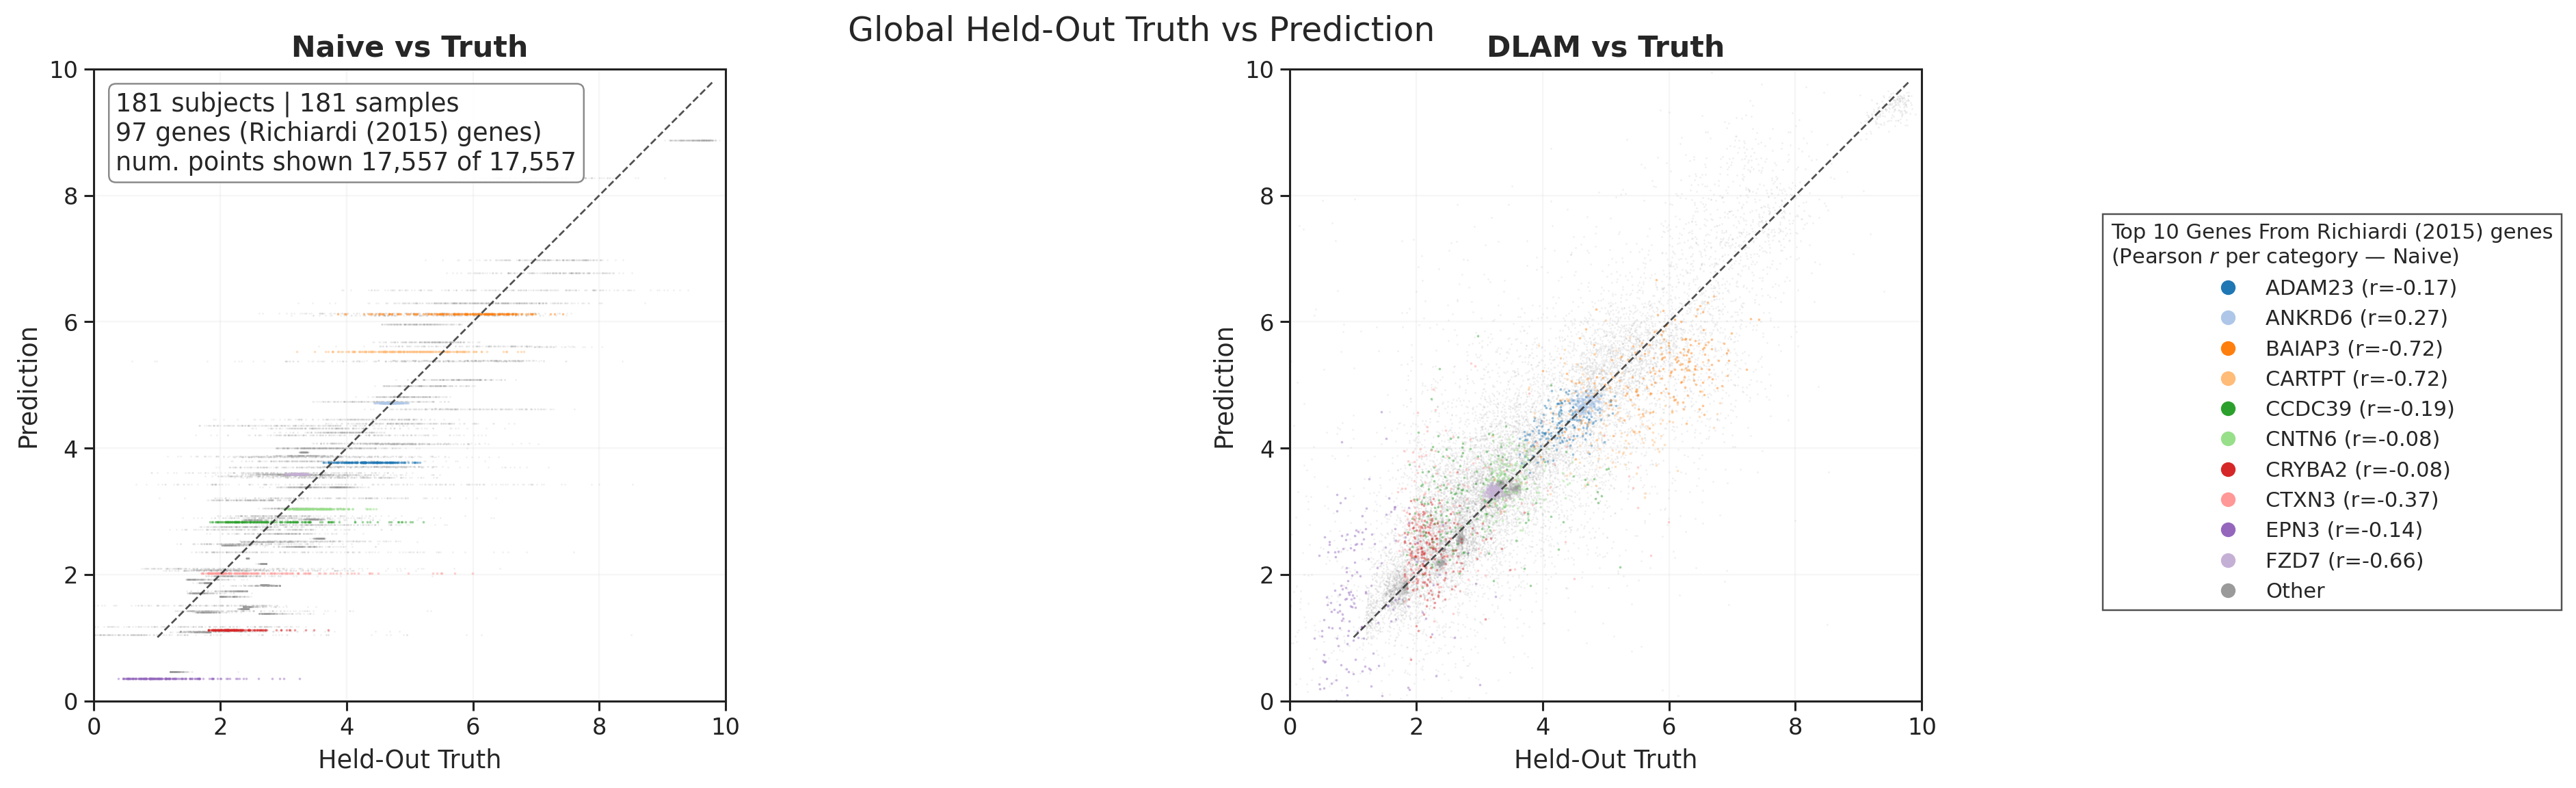

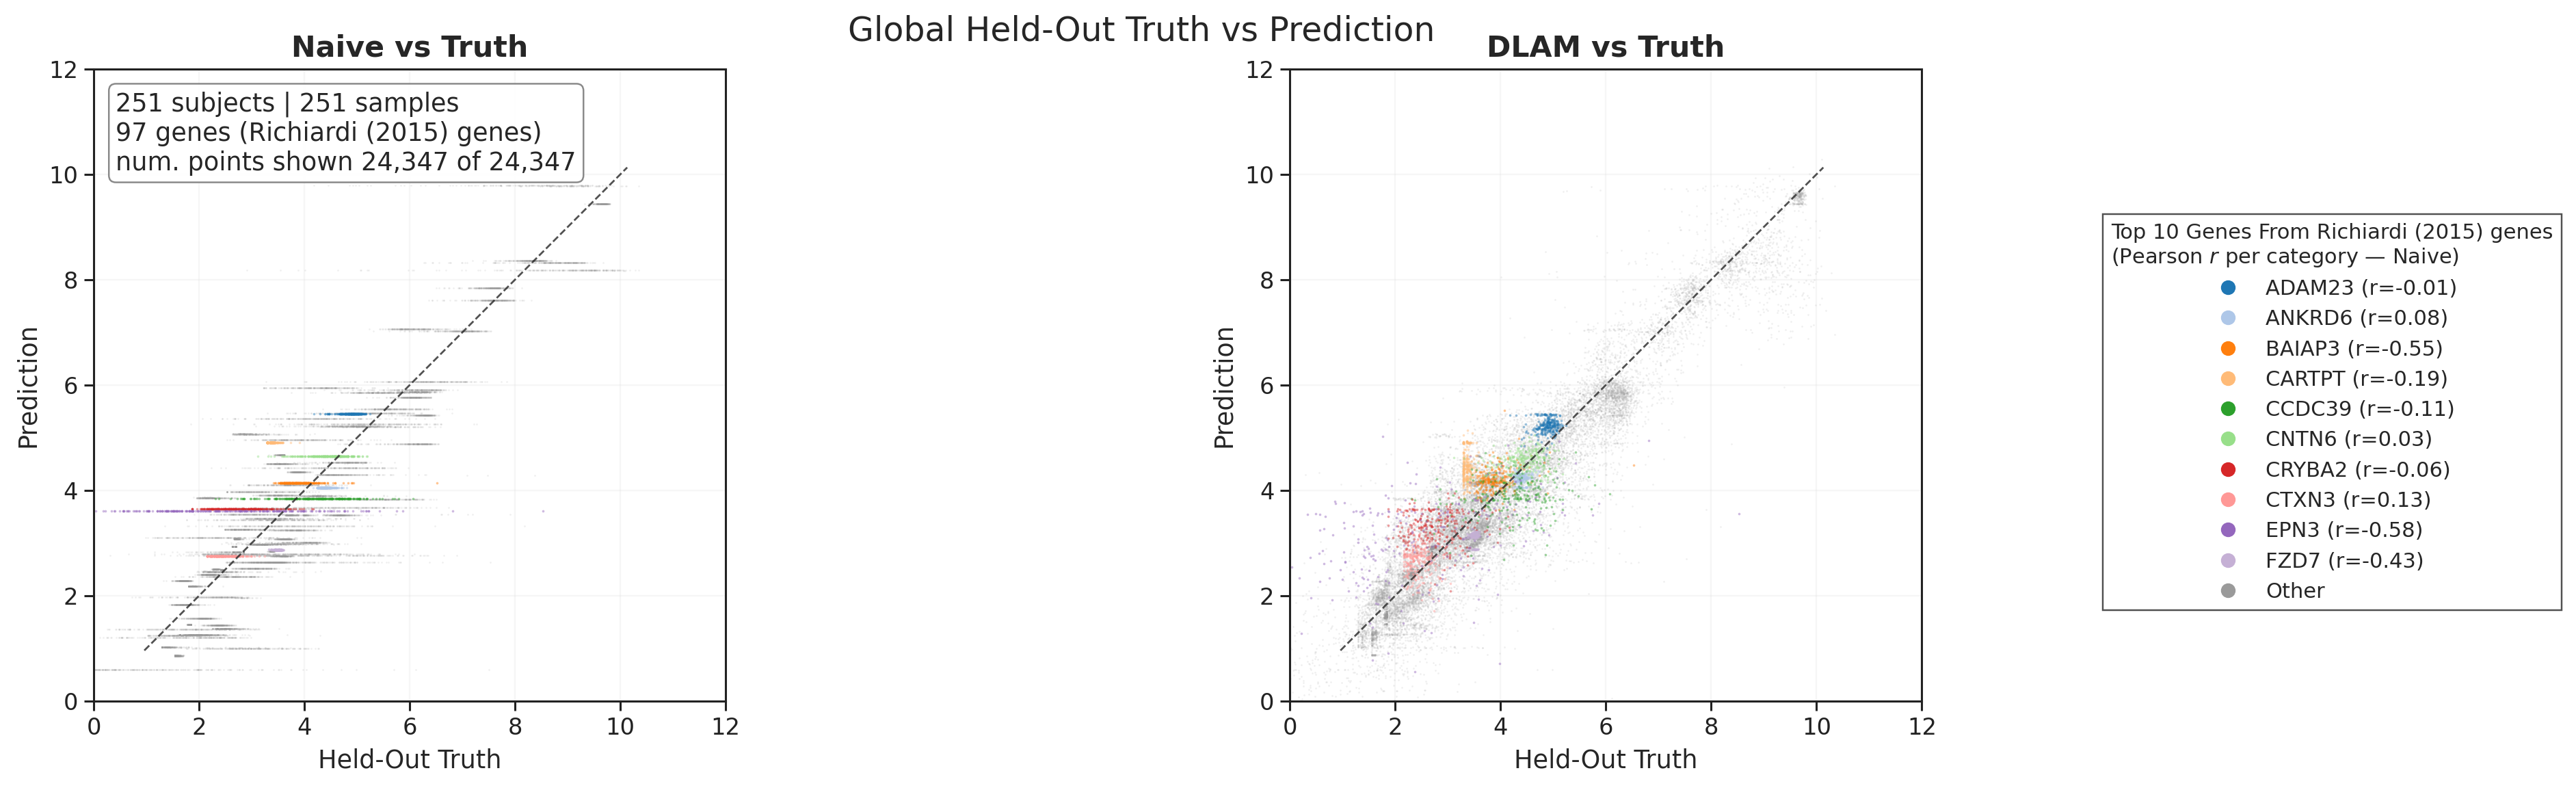

In [22]:
for _tissue in S5_TISSUES:
    _view = build_panel_view(S5_GENE_LIST_PATH, tissues=[_tissue])
    print(f'tissue={_tissue!r}: samples={len(_view["truth_df"])}, genes={len(_view["genes"])}')
    fig, axes = plot_global_prediction_scatter(
        _view,
        color_by=S5_COLOR_BY,
        top_n=S5_TOP_N,
        annotate_metric_in_legend=S5_ANNOTATE_METRIC is not None,
        annotation_metric=S5_ANNOTATE_METRIC,
        figsize=S5_FIGSIZE,
        max_points_per_model=S5_MAX_POINTS,
    )